<a href="https://colab.research.google.com/github/yashika1231/23FE10CSE00734/blob/main/Test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
df = pd.read_csv("store_customers.csv")

print(df.head())
print(df.info())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
None


In [ ]:
df = df.drop("CustomerID", axis=1)

In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [ ]:
df = df.dropna()

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

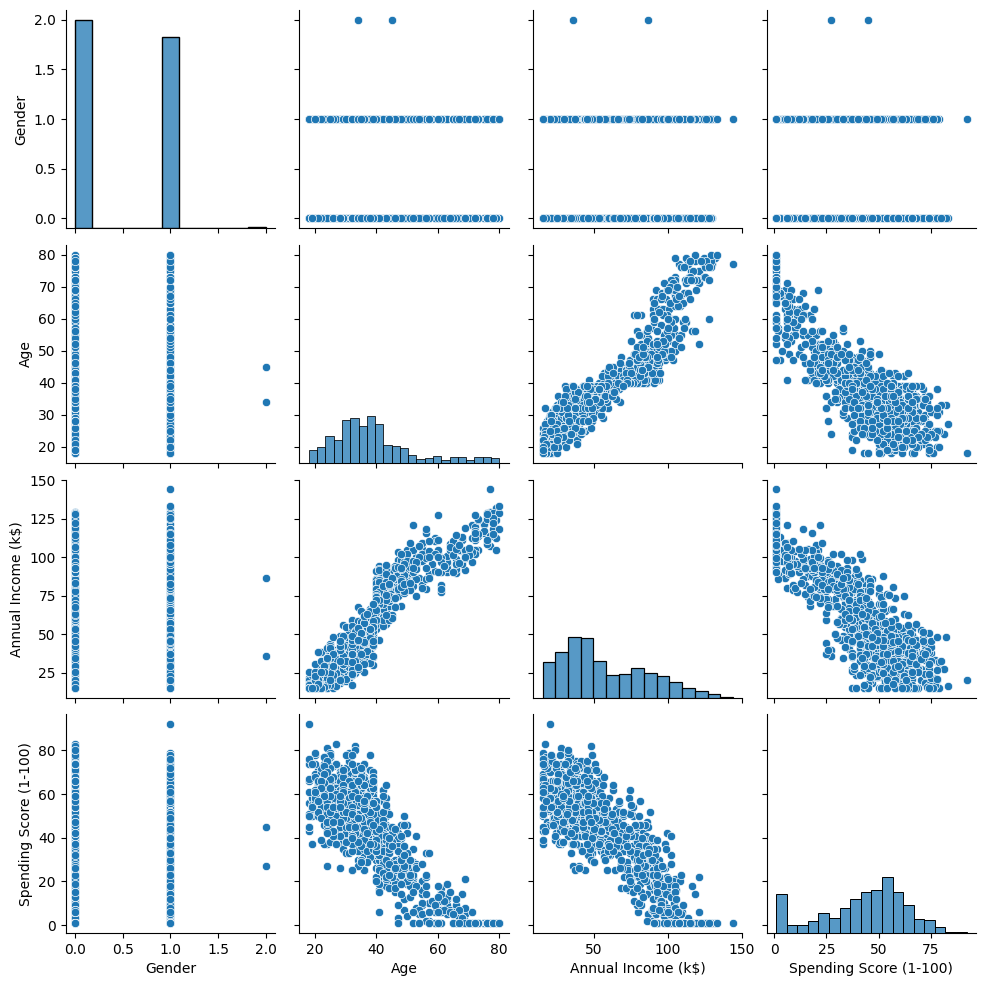

In [ ]:
sns.pairplot(df)
plt.show()

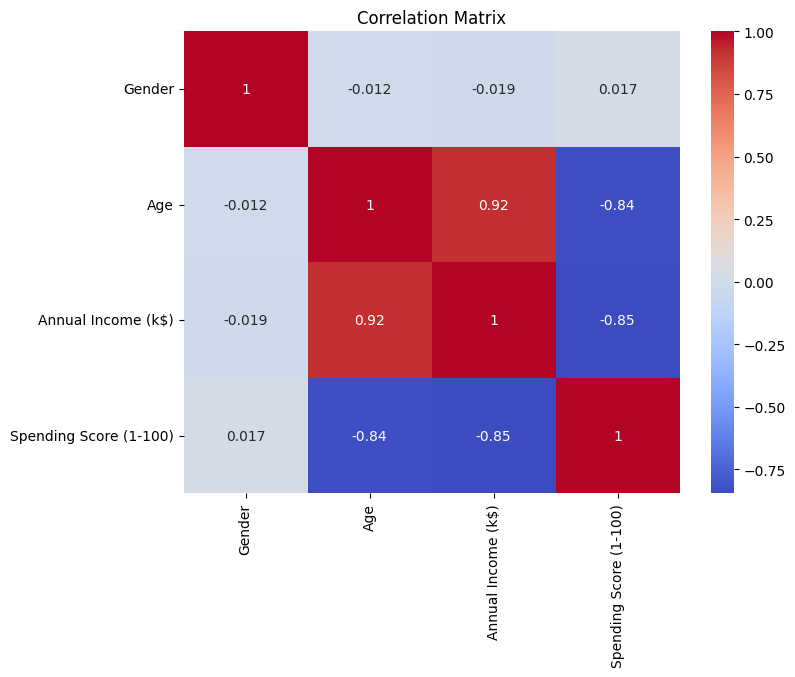

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

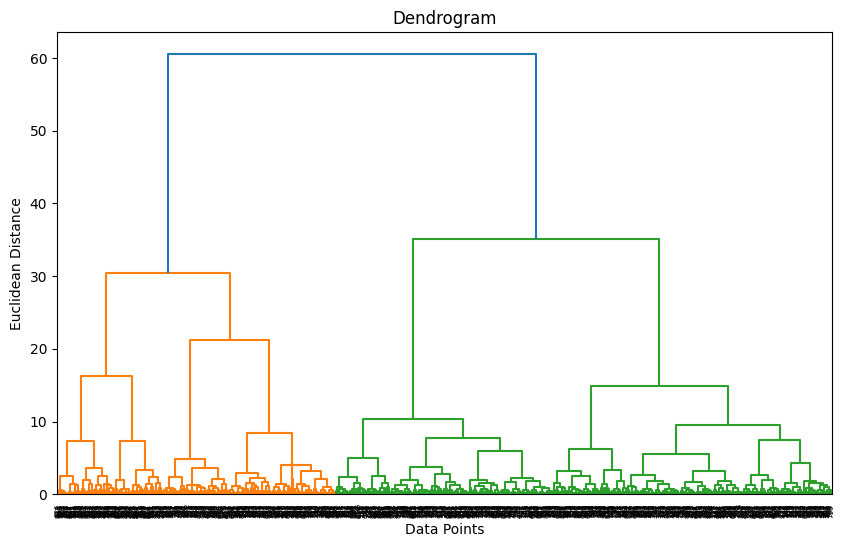

In [ ]:
plt.figure(figsize=(10,6))
linked = linkage(X, method='ward')

dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_pred = hc.fit_predict(X)

In [ ]:
df['Cluster'] = y_pred

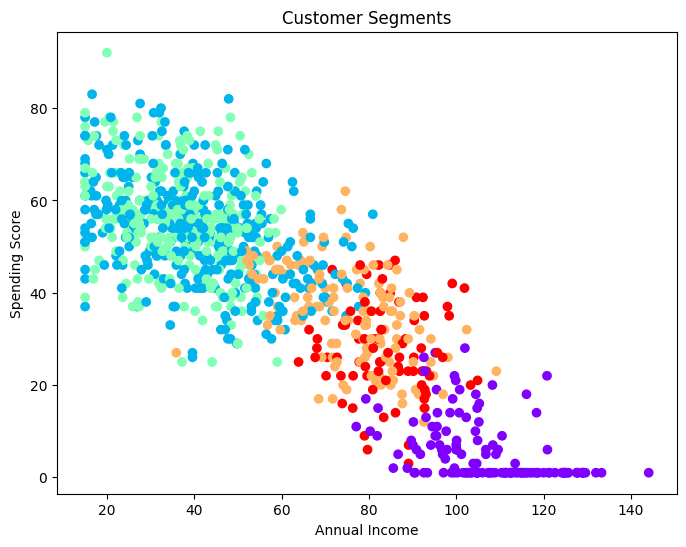

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=y_pred, cmap='rainbow')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [ ]:
score = silhouette_score(X, y_pred)

print("Silhouette Score:", score)

Silhouette Score: 0.4191175637028372
